# Lab Activity: LangChain Agents & Memory

### Step 1: Environment Setup & Imports
To begin, we need to load our environment variables (like API keys) and import the core components from LangChain and Groq. We'll be importing `create_agent` to build our assistant and the `@tool` decorator to give it access to external functions.

In [1]:
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain.tools import tool
from langchain.agents import create_agent

load_dotenv()

True

### Step 2: Defining the Agent's Tools
An LLM on its own only knows what it was trained on. To let it interact with our specific store, we create **Tools**. Notice the `@tool` decorator and the docstrings (`"""Look up a product..."""`). The LLM reads these docstrings to understand *when* and *how* to use these functions to get real-time data from our mock databases.

In [2]:
PRODUCTS = {
    "wireless headphones": {"price": 79.99,  "description": "Over-ear Bluetooth, 30-hr battery, active noise cancellation."},
    "smart watch":         {"price": 199.99, "description": "Tracks heart rate and sleep. 5-day battery, water-resistant."},
    "mechanical keyboard": {"price": 129.00, "description": "Tenkeyless, Cherry MX Brown switches, per-key RGB."},
    "laptop stand":        {"price": 34.99,  "description": "Adjustable aluminium, fits 11-17 inch laptops, folds flat."},
}

REVIEWS = {
    "wireless headphones": {"reviews": 1262, "rating": 4.6},
    "smart watch":         {"reviews": 340,  "rating": 3.9},
    "mechanical keyboard": {"reviews": 67,   "rating": 4.8},
    "laptop stand":        {"reviews": 781,  "rating": 4.5},
}

@tool
def get_product(name: str) -> str:
    """Look up a product by name and return its price, rating, stock, and description."""
    p = PRODUCTS.get(name.lower())
    if not p:
        return f"Product not found. Available: {', '.join(PRODUCTS)}"
    return str(p)
    
@tool
def get_review(name: str) -> str:
    """Look up a product review by a product name. Return the product name, number of reviews and rating"""
    r = REVIEWS.get(name.lower())
    if not r:
        return f"Review not available for this product"
    return str(r)    

### Step 3: Initializing a Stateless Agent
Now we bind our LLM (Groq's Qwen model) to our tools using `create_agent`. Importantly, this agent has **no memory**. It treats every prompt as an entirely isolated event.

In [3]:
llm = ChatGroq(model="qwen/qwen3.8-27b", temperature=0)

agent = create_agent(
    llm,
    tools=[get_product, get_review],
    system_prompt="You are a helpful product assistant for an online tech store.",
)

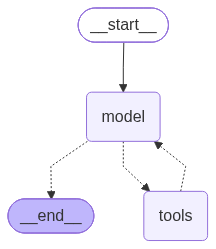

In [10]:
from IPython.display import Image, display

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

### Step 4: Creating a Chat Helper
To make interacting with our agent easier, we'll write a quick helper function that formats our question into the required message structure and prints the final response.

In [4]:
def ask(question: str):
    result = agent.invoke({"messages": [{"role": "user", "content": question}]})
    print(result["messages"][-1].content)

### Step 5: Testing Tool Execution
Let's ask a direct question. The agent will successfully recognize that it needs to use the `get_product` tool, execute it with the argument 'wireless headphones', and format the output.

In [5]:
ask("what is the price of wireless headphones.")

The wireless headphones are priced at **$79.99**.

They feature over-ear Bluetooth connectivity, a 30-hour battery life, and active noise cancellation.


### Step 6: The Amnesia Problem (Stateless Failure)
If we ask a follow-up question using a pronoun ("this product"), the agent will fail. Because we haven't provided a memory checkpointer, the agent has completely forgotten our previous conversation about the wireless headphones.

In [6]:
ask("what are the reviews on this product")


I'd be happy to help you find reviews! However, I need to know which product you're asking about. Could you please provide the name of the product you'd like me to look up reviews for?


### Step 7: Solving Amnesia with LangGraph Memory
To fix this, we create a new agent (`agent2`). This time, we pass an `InMemorySaver()` to the `checkpointer` argument. This saves the history of our conversation graph. We also update our ask function to include a `thread_id`, which tells the agent which specific conversation history to look up.

In [7]:
from langgraph.checkpoint.memory import InMemorySaver

llm = ChatGroq(model="qwen/qwen3.8-27b", temperature=0)

agent2 = create_agent(
    llm,
    tools=[get_product, get_review],
    system_prompt="You are a helpful product assistant for an online tech store.",
    checkpointer=InMemorySaver()
)

def ask2(question: str):
    config = {"configurable": {"thread_id": "user-alice-session-1"}}
    result = agent2.invoke(
        {"messages": [{"role": "user", "content": question}]},
        config
    )
    print(result["messages"][-1].content)

### Step 8: Establishing Context
We ask the exact same initial question to our new, memory-enabled agent. It fetches the product details just like before, but this time, the state is saved to `thread_id: user-alice-session-1`.

In [8]:
ask2("what is the price of wireless headphones.")

The wireless headphones are priced at **$79.99**.

They feature over-ear Bluetooth connectivity, a 30-hour battery life, and active noise cancellation.


### Step 9: Proving Memory Context
Now we ask the vague follow-up question. Because the agent's checkpointer retrieves the history of `user-alice-session-1`, the LLM knows "this product" refers to the "wireless headphones". It successfully routes that resolved name into the `get_review` tool.

In [9]:
ask2("what are the reviews on this product")

The wireless headphones have an average rating of **4.6 out of 5** based on **1,262 reviews**.
